# Data Loading/Processing/Cleaning

In [ ]:
import pandas as pd
import numpy as np

# Load the data (.csv file)
df = pd.read_csv("Epileptic Seizure Recognition.csv")

# Drop the unwanted index column that Kaggle/UCI Machine Learning Repository often adds
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print(df.head())           # Check the first few rows
print(df.dtypes)           # See current data types

# Convert all feature columns (X1 to X178) to numeric
feature_cols = [col for col in df.columns if col.startswith('X')]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')

# Also ensure target is integer
df['y'] = pd.to_numeric(df['y'], errors='coerce').astype(int)

# Now create X_raw as numeric array
X_raw = df[feature_cols].values   # or df.iloc[:, :-1].values after cleaning

print(X_raw.dtype)  # Should now be float64 or int64


      Unnamed   X1   X2   X3   X4   X5   X6   X7   X8   X9  ...  X170  X171  \
0  X21.V1.791  135  190  229  223  192  125   55   -9  -33  ...   -17   -15   
1  X15.V1.924  386  382  356  331  320  315  307  272  244  ...   164   150   
2     X8.V1.1  -32  -39  -47  -37  -32  -36  -57  -73  -85  ...    57    64   
3   X16.V1.60 -105 -101  -96  -92  -89  -95 -102 -100  -87  ...   -82   -81   
4   X20.V1.54   -9  -65  -98 -102  -78  -48  -16    0  -21  ...     4     2   

   X172  X173  X174  X175  X176  X177  X178  y  
0   -31   -77  -103  -127  -116   -83   -51  4  
1   146   152   157   156   154   143   129  1  
2    48    19   -12   -30   -35   -35   -36  5  
3   -80   -77   -85   -77   -72   -69   -65  5  
4   -12   -32   -41   -65   -83   -89   -73  5  

[5 rows x 180 columns]
Unnamed    object
X1          int64
X2          int64
X3          int64
X4          int64
            ...  
X175        int64
X176        int64
X177        int64
X178        int64
y           int64
Length: 1

In [ ]:
print(df.columns.tolist())
print("Duplicate columns:", df.columns[df.columns.duplicated()].tolist())

#Checking for Duplications

['Unnamed', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'X50', 'X51', 'X52', 'X53', 'X54', 'X55', 'X56', 'X57', 'X58', 'X59', 'X60', 'X61', 'X62', 'X63', 'X64', 'X65', 'X66', 'X67', 'X68', 'X69', 'X70', 'X71', 'X72', 'X73', 'X74', 'X75', 'X76', 'X77', 'X78', 'X79', 'X80', 'X81', 'X82', 'X83', 'X84', 'X85', 'X86', 'X87', 'X88', 'X89', 'X90', 'X91', 'X92', 'X93', 'X94', 'X95', 'X96', 'X97', 'X98', 'X99', 'X100', 'X101', 'X102', 'X103', 'X104', 'X105', 'X106', 'X107', 'X108', 'X109', 'X110', 'X111', 'X112', 'X113', 'X114', 'X115', 'X116', 'X117', 'X118', 'X119', 'X120', 'X121', 'X122', 'X123', 'X124', 'X125', 'X126', 'X127', 'X128', 'X129', 'X130', 'X131', 'X132', 'X133', 'X134', 'X135', 'X136', 'X137', 

In [ ]:
# Removes duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# Confirm
print("Columns after fix:", df.columns.tolist())
print("Total columns:", len(df.columns))

Columns after fix: ['Unnamed', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'X50', 'X51', 'X52', 'X53', 'X54', 'X55', 'X56', 'X57', 'X58', 'X59', 'X60', 'X61', 'X62', 'X63', 'X64', 'X65', 'X66', 'X67', 'X68', 'X69', 'X70', 'X71', 'X72', 'X73', 'X74', 'X75', 'X76', 'X77', 'X78', 'X79', 'X80', 'X81', 'X82', 'X83', 'X84', 'X85', 'X86', 'X87', 'X88', 'X89', 'X90', 'X91', 'X92', 'X93', 'X94', 'X95', 'X96', 'X97', 'X98', 'X99', 'X100', 'X101', 'X102', 'X103', 'X104', 'X105', 'X106', 'X107', 'X108', 'X109', 'X110', 'X111', 'X112', 'X113', 'X114', 'X115', 'X116', 'X117', 'X118', 'X119', 'X120', 'X121', 'X122', 'X123', 'X124', 'X125', 'X126', 'X127', 'X128', 'X129', 'X130', 'X131', 'X132', 'X133', 'X134', 'X135

In [ ]:
# Drop any column that starts with 'Unnamed'
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
print("Shape after dropping Unnamed:", df.shape)

Shape after dropping Unnamed: (11500, 179)


In [ ]:
# Confirm clean DataFrame structure
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Duplicates:", df.columns[df.columns.duplicated()].tolist())
print("Null values:", df.isnull().sum().sum())
print("dtypes:\n", df.dtypes.value_counts())

Shape: (11500, 179)
Columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'X50', 'X51', 'X52', 'X53', 'X54', 'X55', 'X56', 'X57', 'X58', 'X59', 'X60', 'X61', 'X62', 'X63', 'X64', 'X65', 'X66', 'X67', 'X68', 'X69', 'X70', 'X71', 'X72', 'X73', 'X74', 'X75', 'X76', 'X77', 'X78', 'X79', 'X80', 'X81', 'X82', 'X83', 'X84', 'X85', 'X86', 'X87', 'X88', 'X89', 'X90', 'X91', 'X92', 'X93', 'X94', 'X95', 'X96', 'X97', 'X98', 'X99', 'X100', 'X101', 'X102', 'X103', 'X104', 'X105', 'X106', 'X107', 'X108', 'X109', 'X110', 'X111', 'X112', 'X113', 'X114', 'X115', 'X116', 'X117', 'X118', 'X119', 'X120', 'X121', 'X122', 'X123', 'X124', 'X125', 'X126', 'X127', 'X128', 'X129', 'X130', 'X131', 'X132', 'X133', 'X134', 'X135'

# Checking for Organization and Class Imbalance

In [ ]:
#Checks for organization from columns
print(df.columns)

#Check for class imbalance for RandomForestClassifier to operate
print(df['y'].value_counts())

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10',
       ...
       'X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178',
       'y'],
      dtype='object', length=179)
y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64


# Plotting single EEG dataset as a Line Graph Function of Signal Amplitude and Time

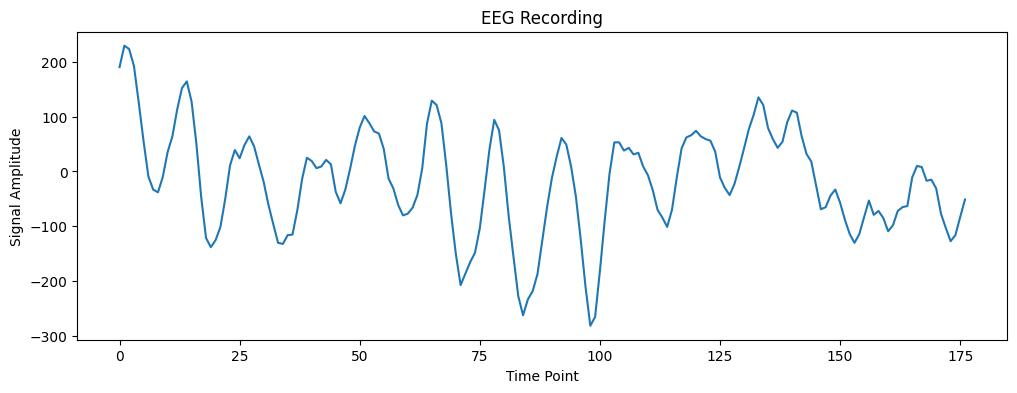

In [ ]:
# Foundation for how all information in Data Set is interpreted
import matplotlib.pyplot as plt

# Extracts the row 0 of the data (EEG Raw Recording)
sample = df.iloc[0, 1:-1]

# Sizing figure for time-series signals (For measuring amplitude of signal across a time period)
plt.figure(figsize=(12,4))

# Labeling graph
plt.plot(sample.values)
plt.title("EEG Recording")
plt.xlabel("Time Point")
plt.ylabel("Signal Amplitude")
plt.show()


# Displaying Summary Statistics


In [ ]:
feature_cols = [col for col in df.columns if col.startswith('X')]

# Add all new columns in a single operation — no fragmentation
df = df.assign(
    mean_amplitude  = df[feature_cols].mean(axis=1),
    std_amplitude   = df[feature_cols].std(axis=1),
    range_amplitude = df[feature_cols].max(axis=1) - df[feature_cols].min(axis=1)
)

summary_by_class = df.groupby('y')[['mean_amplitude', 'std_amplitude', 'range_amplitude']].mean()
summary_by_class.index = summary_by_class.index.map({
    1: "Seizure", 2: "Tumor Area", 3: "Healthy Area",
    4: "Eyes Closed", 5: "Eyes Open"
})
print(summary_by_class)

              mean_amplitude  std_amplitude  range_amplitude
y                                                           
Seizure            -4.760684     303.472484      1382.224348
Tumor Area         -6.202807      60.629722       282.688696
Healthy Area       -8.881236      47.785376       213.739565
Eyes Closed       -12.511610      59.192105       287.543478
Eyes Open          -6.255845      38.532194       188.862174


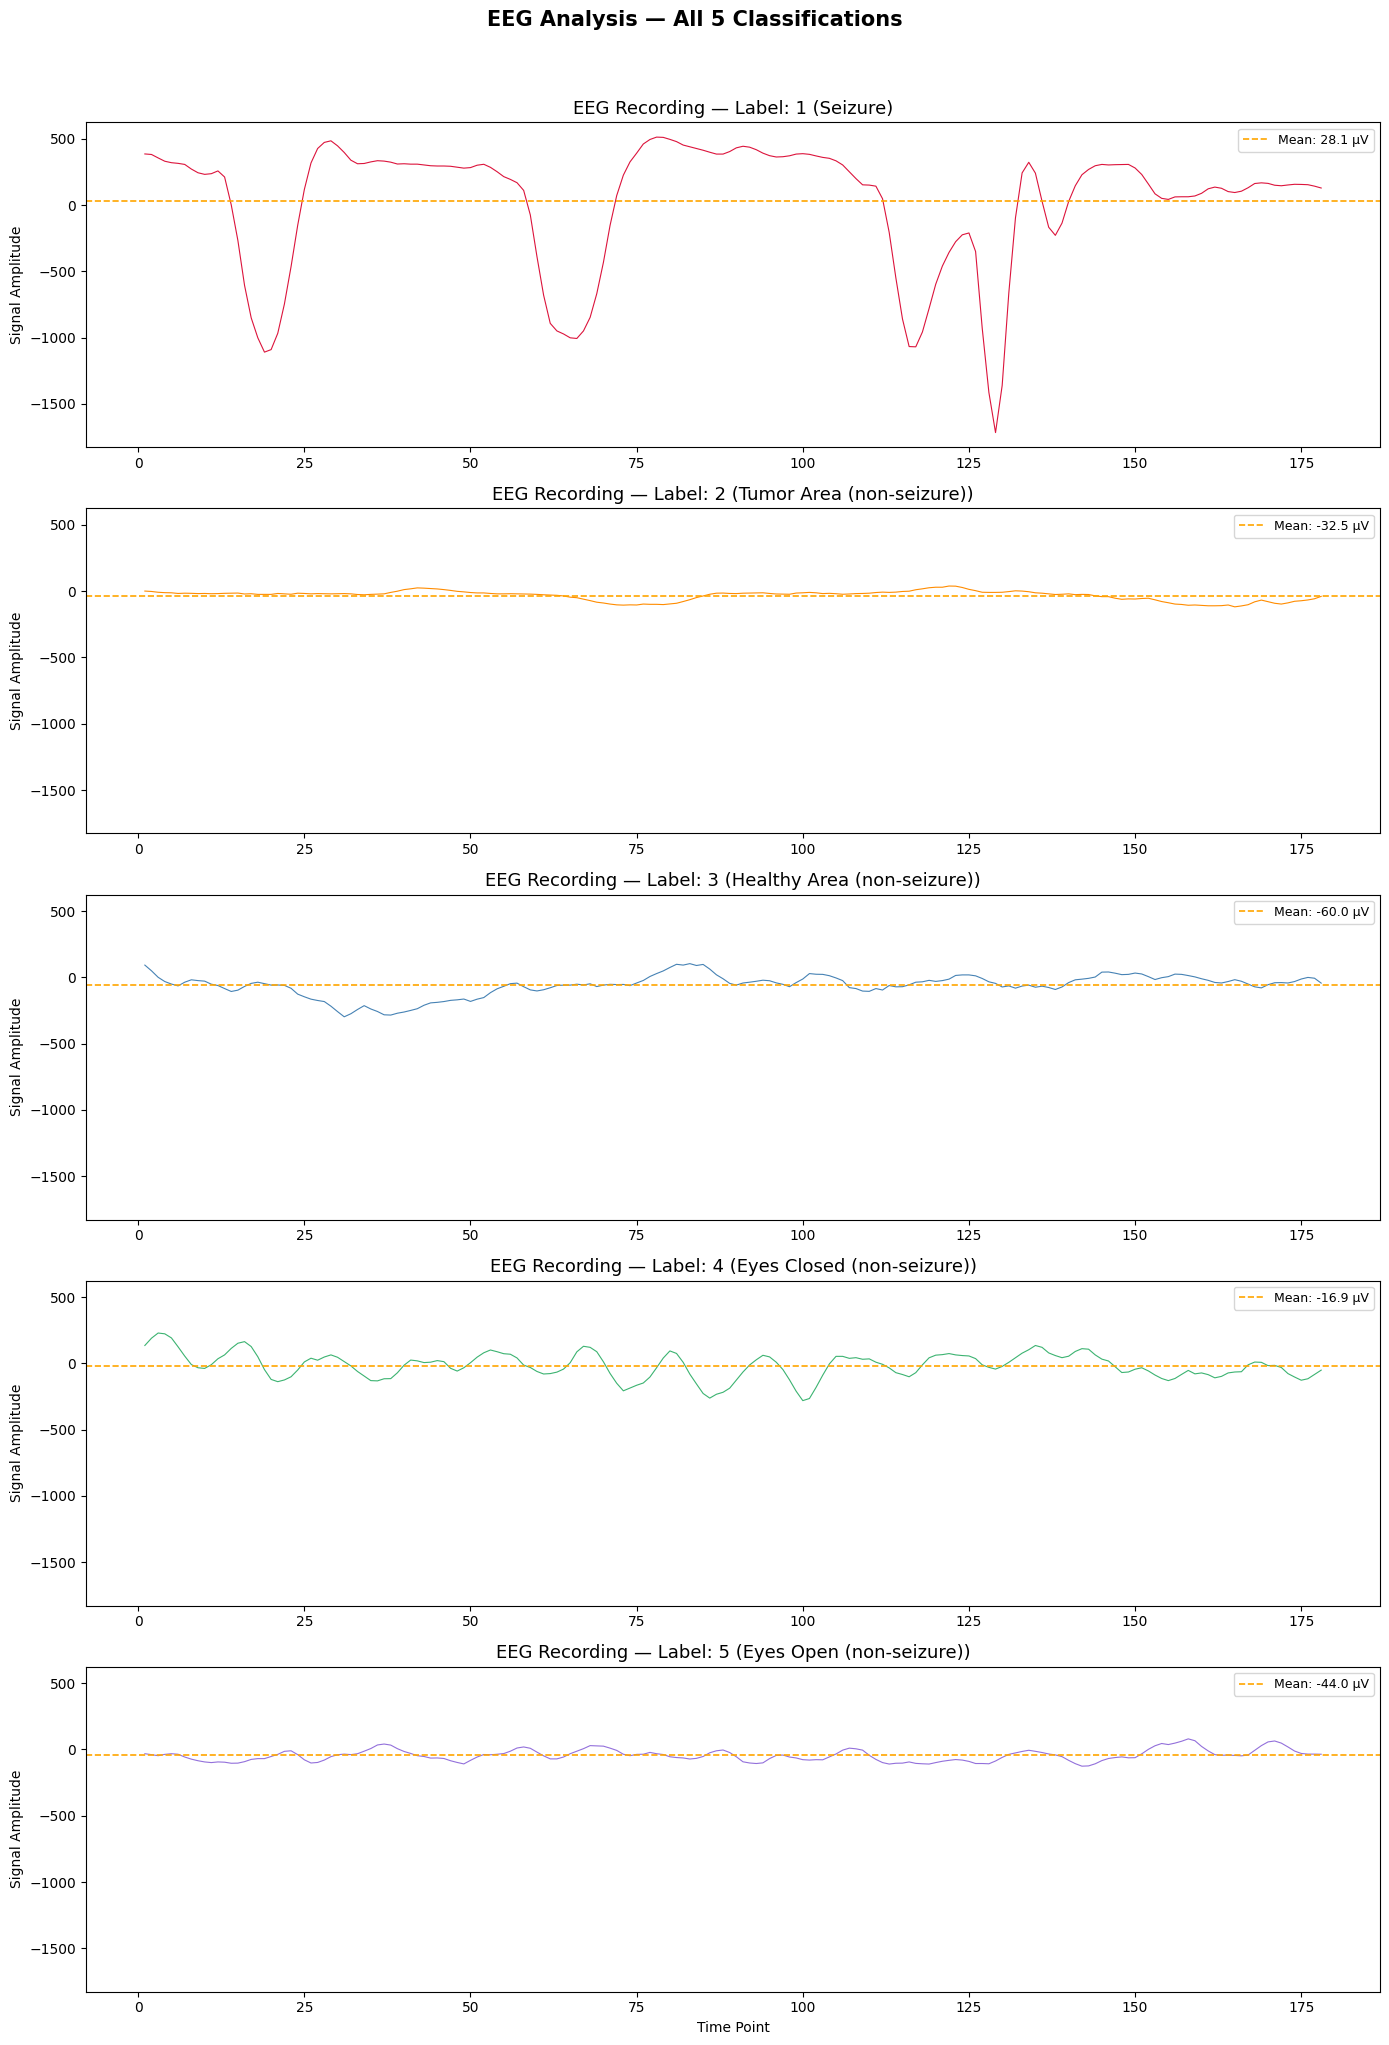

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

label_map = {
    1: "Seizure",
    2: "Tumor Area (non-seizure)",
    3: "Healthy Area (non-seizure)",
    4: "Eyes Closed (non-seizure)",
    5: "Eyes Open (non-seizure)"
}

color_map = {
    1: "crimson",
    2: "darkorange",
    3: "steelblue",
    4: "mediumseagreen",
    5: "mediumpurple"
}

feature_cols = [col for col in df.columns if col.startswith('X')]  # ← fix

samples = {}
for class_id in label_map:
    row = df[df['y'] == class_id].iloc[0]
    samples[class_id] = {
        "signal": row[feature_cols],  # ← fix
        "label":  row['y']            # ← fix
    }

time_points = range(1, 179)

fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=False, sharey=True)

for ax, (class_id, data) in zip(axes, samples.items()):
    signal   = data["signal"].values
    mean_val = np.mean(signal)

    ax.plot(time_points, signal,
            color=color_map[class_id], linewidth=0.8)

    ax.axhline(y=mean_val, color='orange', linestyle='--',
               linewidth=1.2, label=f'Mean: {mean_val:.1f} μV')

    ax.set_title(
        f"EEG Recording — Label: {class_id} ({label_map[class_id]})",
        fontsize=13
    )
    ax.set_ylabel("Signal Amplitude")
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel("Time Point")

plt.suptitle(
    "EEG Analysis — All 5 Classifications",
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# Plotting Dominant Frequency over Average Amplitude for the 5 Classification -> Then labeling the frequency range and Mean Amplitude of the 5 Classifications

## Top View | 3D View

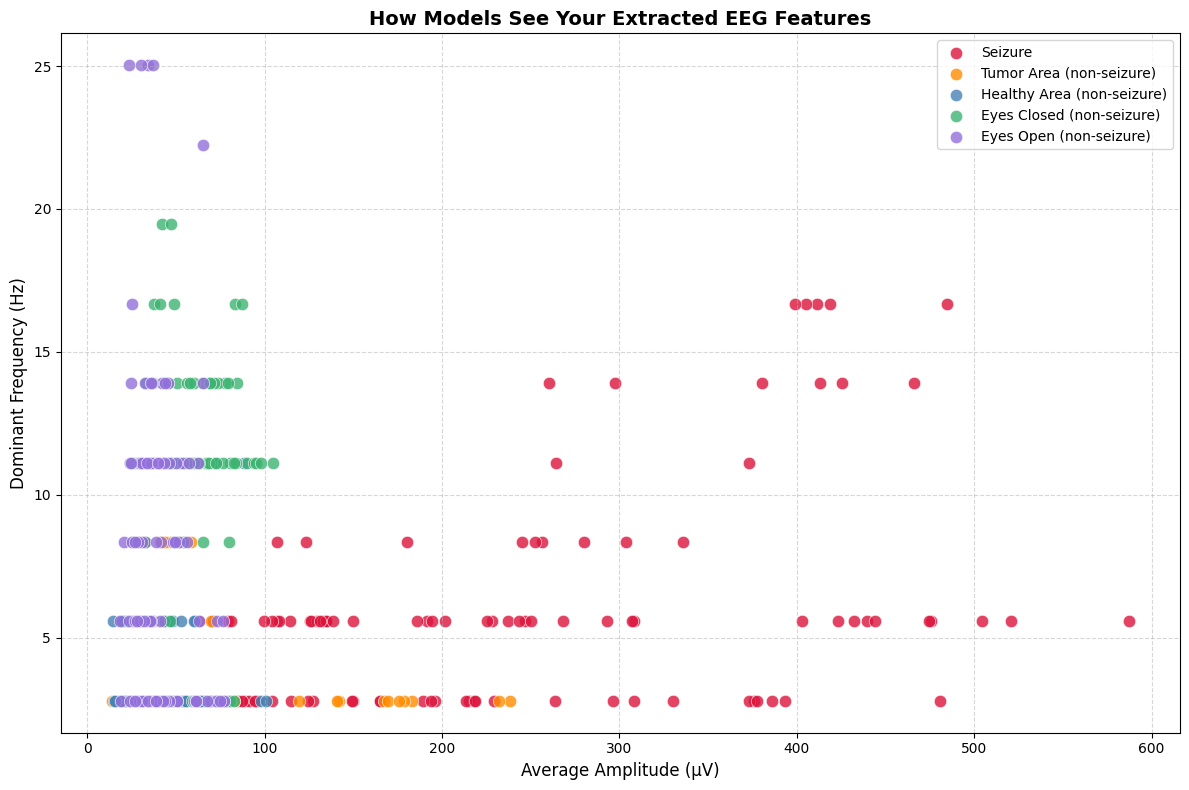

Dominant Frequency Ranges by Class
Seizure
  Range : 2.78 Hz — 16.69 Hz
  Mean  : 6.01 Hz
---------------------------------------------
Tumor Area (non-seizure)
  Range : 2.78 Hz — 8.34 Hz
  Mean  : 3.84 Hz
---------------------------------------------
Healthy Area (non-seizure)
  Range : 2.78 Hz — 11.12 Hz
  Mean  : 3.48 Hz
---------------------------------------------
Eyes Closed (non-seizure)
  Range : 2.78 Hz — 19.47 Hz
  Mean  : 10.65 Hz
---------------------------------------------
Eyes Open (non-seizure)
  Range : 2.78 Hz — 25.03 Hz
  Mean  : 7.79 Hz
---------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Label map and color map
label_map = {
    1: "Seizure",
    2: "Tumor Area (non-seizure)",
    3: "Healthy Area (non-seizure)",
    4: "Eyes Closed (non-seizure)",
    5: "Eyes Open (non-seizure)"
}

color_map = {
    1: "crimson",
    2: "darkorange",
    3: "steelblue",
    4: "mediumseagreen",
    5: "mediumpurple"
}

feature_cols = [col for col in df.columns if col.startswith('X')]

# Extract 100 samples per class and compute features
scatter_data = []

for class_id in label_map:
    samples = df[df['y'] == class_id].head(100)

    for _, row in samples.iterrows():
        signal = row[feature_cols].values.astype(float)

        # Feature 1 — Average Amplitude
        avg_amplitude = np.mean(np.abs(signal))

        # Feature 2 — Dominant Frequency via Welch Power Spectral Density
        freqs, power = welch(signal, fs=178.0, nperseg=64)
        dominant_freq = freqs[np.argmax(power)]

        scatter_data.append({
            "class_id":       class_id,
            "avg_amplitude":  avg_amplitude,
            "dominant_freq":  dominant_freq
        })

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

for class_id, label in label_map.items():
    class_points = [d for d in scatter_data if d["class_id"] == class_id]
    x = [d["avg_amplitude"] for d in class_points]
    y = [d["dominant_freq"]  for d in class_points]

    ax.scatter(x, y,
               color=color_map[class_id],
               label=label,
               s=80,
               alpha=0.8,
               edgecolors='white',
               linewidths=0.5)

ax.set_title("How Models See Your Extracted EEG Features", fontsize=14, fontweight='bold')
ax.set_xlabel("Average Amplitude (μV)", fontsize=12)
ax.set_ylabel("Dominant Frequency (Hz)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Compute dominant frequency range per class from the scatter data
print("Dominant Frequency Ranges by Class")
print("=" * 45)

for class_id, label in label_map.items():
    class_points = [d for d in scatter_data if d["class_id"] == class_id]
    freqs = [d["dominant_freq"] for d in class_points]

    min_freq  = min(freqs)
    max_freq  = max(freqs)
    mean_freq = np.mean(freqs)

    print(f"{label}")
    print(f"  Range : {min_freq:.2f} Hz — {max_freq:.2f} Hz")
    print(f"  Mean  : {mean_freq:.2f} Hz")
    print("-" * 45)

#

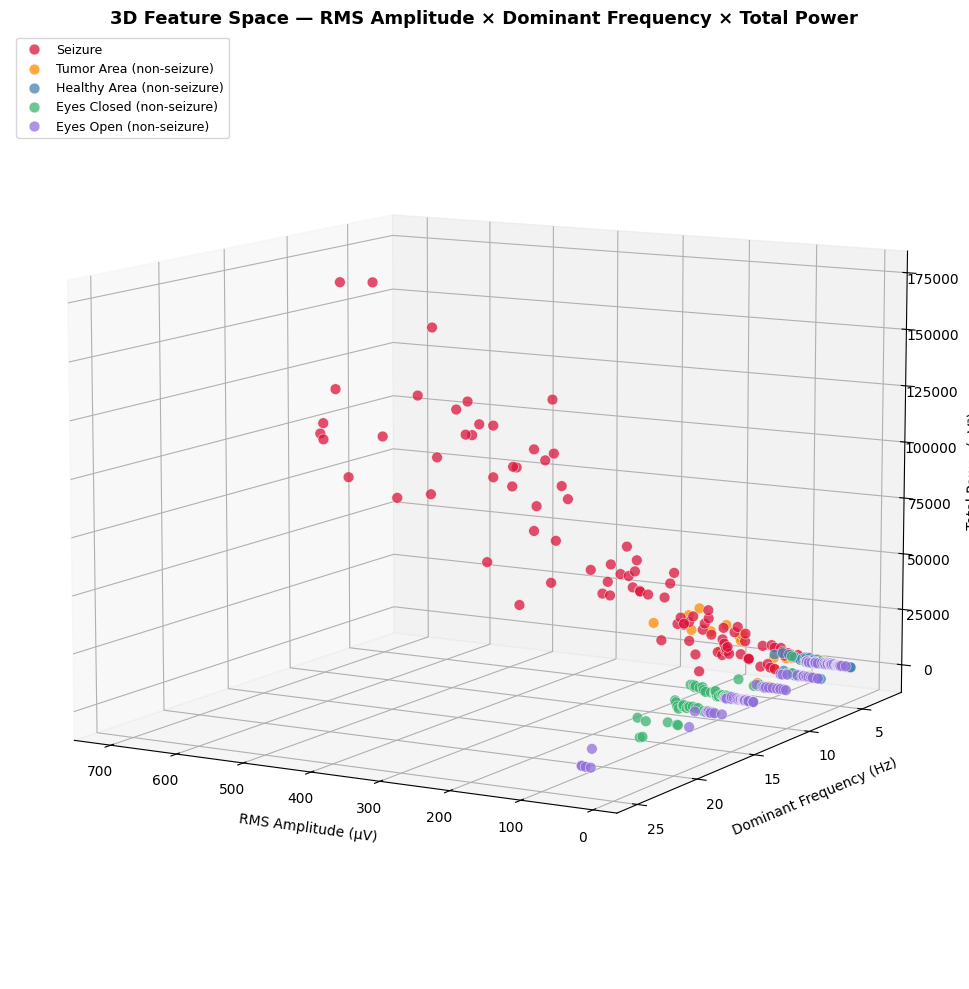

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import welch

label_map = {
    1: "Seizure",
    2: "Tumor Area (non-seizure)",
    3: "Healthy Area (non-seizure)",
    4: "Eyes Closed (non-seizure)",
    5: "Eyes Open (non-seizure)"
}

color_map = {
    1: "crimson",
    2: "darkorange",
    3: "steelblue",
    4: "mediumseagreen",
    5: "mediumpurple"
}

feature_cols = [col for col in df.columns if col.startswith('X')]

# Extract 100 samples per class — RMS, Dominant Freq, Total Power
scatter_data_3d = []

for class_id in label_map:
    samples = df[df['y'] == class_id].head(100)

    for _, row in samples.iterrows():
        signal = row[feature_cols].values.astype(float)

        rms_amplitude = np.sqrt(np.mean(signal**2))

        freqs, power = welch(signal, fs=178.0, nperseg=64)
        dominant_freq = freqs[np.argmax(power)]
        total_power   = np.sum(power)   # z-axis

        scatter_data_3d.append({
            "class_id":      class_id,
            "rms_amplitude": rms_amplitude,
            "dominant_freq": dominant_freq,
            "total_power":   total_power
        })

# 3D Plot
fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(111, projection='3d')

for class_id, label in label_map.items():
    class_points = [d for d in scatter_data_3d if d["class_id"] == class_id]
    x = [d["rms_amplitude"] for d in class_points]
    y = [d["dominant_freq"]  for d in class_points]
    z = [d["total_power"]    for d in class_points]

    ax.scatter(x, y, z,
               color=color_map[class_id],
               label=label,
               s=60,
               alpha=0.75,
               edgecolors='white',
               linewidths=0.4)

ax.set_title("3D Feature Space — RMS Amplitude × Dominant Frequency × Total Power",
             fontsize=13, fontweight='bold')
ax.set_xlabel("RMS Amplitude (μV)", fontsize=10, labelpad=10)
ax.set_ylabel("Dominant Frequency (Hz)", fontsize=10, labelpad=10)
ax.set_zlabel("Total Power (μV²)", fontsize=10, labelpad=10)
ax.legend(fontsize=9, loc='upper left')

ax.view_init(elev=10, azim=120)

plt.tight_layout()
plt.show()

# Running Diagnostic for Data Filtering

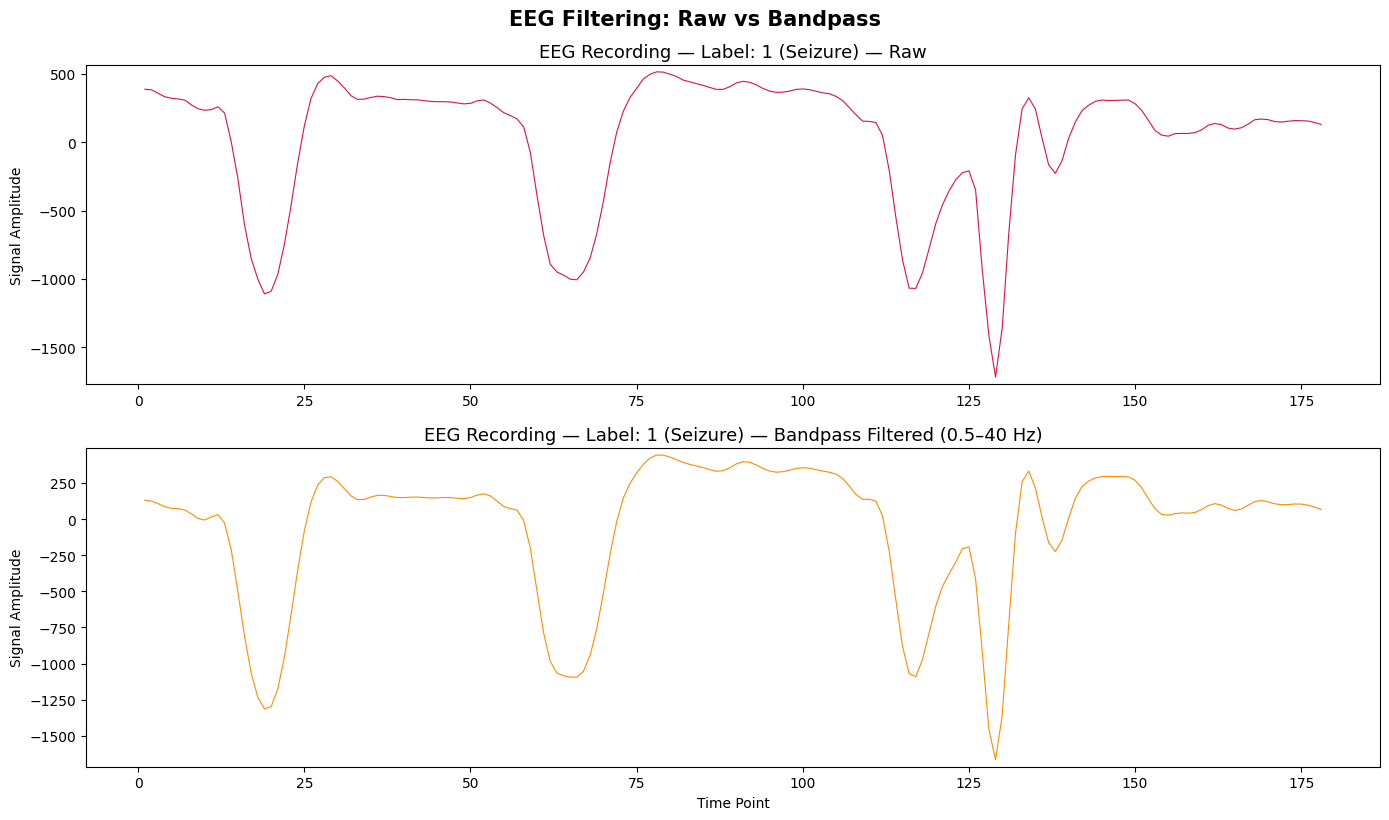

In [ ]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# Define seizure sample
feature_cols     = [col for col in df.columns if col.startswith('X')]
seizure_row      = df[df['y'] == 1].iloc[0]
seizure_sample   = seizure_row[feature_cols]
time_points      = range(1, 179)

def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=178.0, order=4):
    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

seizure_filtered = bandpass_filter(seizure_sample.values)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(time_points, seizure_sample.values, color='crimson', linewidth=0.8)
ax1.set_title("EEG Recording — Label: 1 (Seizure) — Raw", fontsize=13)
ax1.set_ylabel("Signal Amplitude")
ax1.tick_params(axis='x', labelbottom=True)
ax1.tick_params(axis='y', labelleft=True)

ax2.plot(time_points, seizure_filtered, color='darkorange', linewidth=0.8)
ax2.set_title("EEG Recording — Label: 1 (Seizure) — Bandpass Filtered (0.5–40 Hz)", fontsize=13)
ax2.set_xlabel("Time Point")
ax2.set_ylabel("Signal Amplitude")
ax2.tick_params(axis='x', labelbottom=True)
ax2.tick_params(axis='y', labelleft=True)

ax1.set_ylim(seizure_sample.values.min() - 50, seizure_sample.values.max() + 50)
ax2.set_ylim(seizure_filtered.min() - 50, seizure_filtered.max() + 50)

plt.suptitle("EEG Filtering: Raw vs Bandpass", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [ ]:
# Check how different the signals actually are
difference = seizure_sample.values - seizure_filtered
print("Max difference:", difference.max())
print("Min difference:", difference.min())
print("Mean difference:", difference.mean())

Max difference: 257.848614284606
Min difference: -52.53171465817286
Mean difference: 86.20230895301404


In [ ]:
print("Raw min:", seizure_sample.values.min())
print("Raw max:", seizure_sample.values.max())
print("Filtered min:", seizure_filtered.min())
print("Filtered max:", seizure_filtered.max())
print("Raw range:", seizure_sample.values.max() - seizure_sample.values.min())
print("Filtered range:", seizure_filtered.max() - seizure_filtered.min())

Raw min: -1716.0
Raw max: 513.0
Filtered min: -1663.4682853418271
Filtered max: 443.03853265261085
Raw range: 2229.0
Filtered range: 2106.506817994438


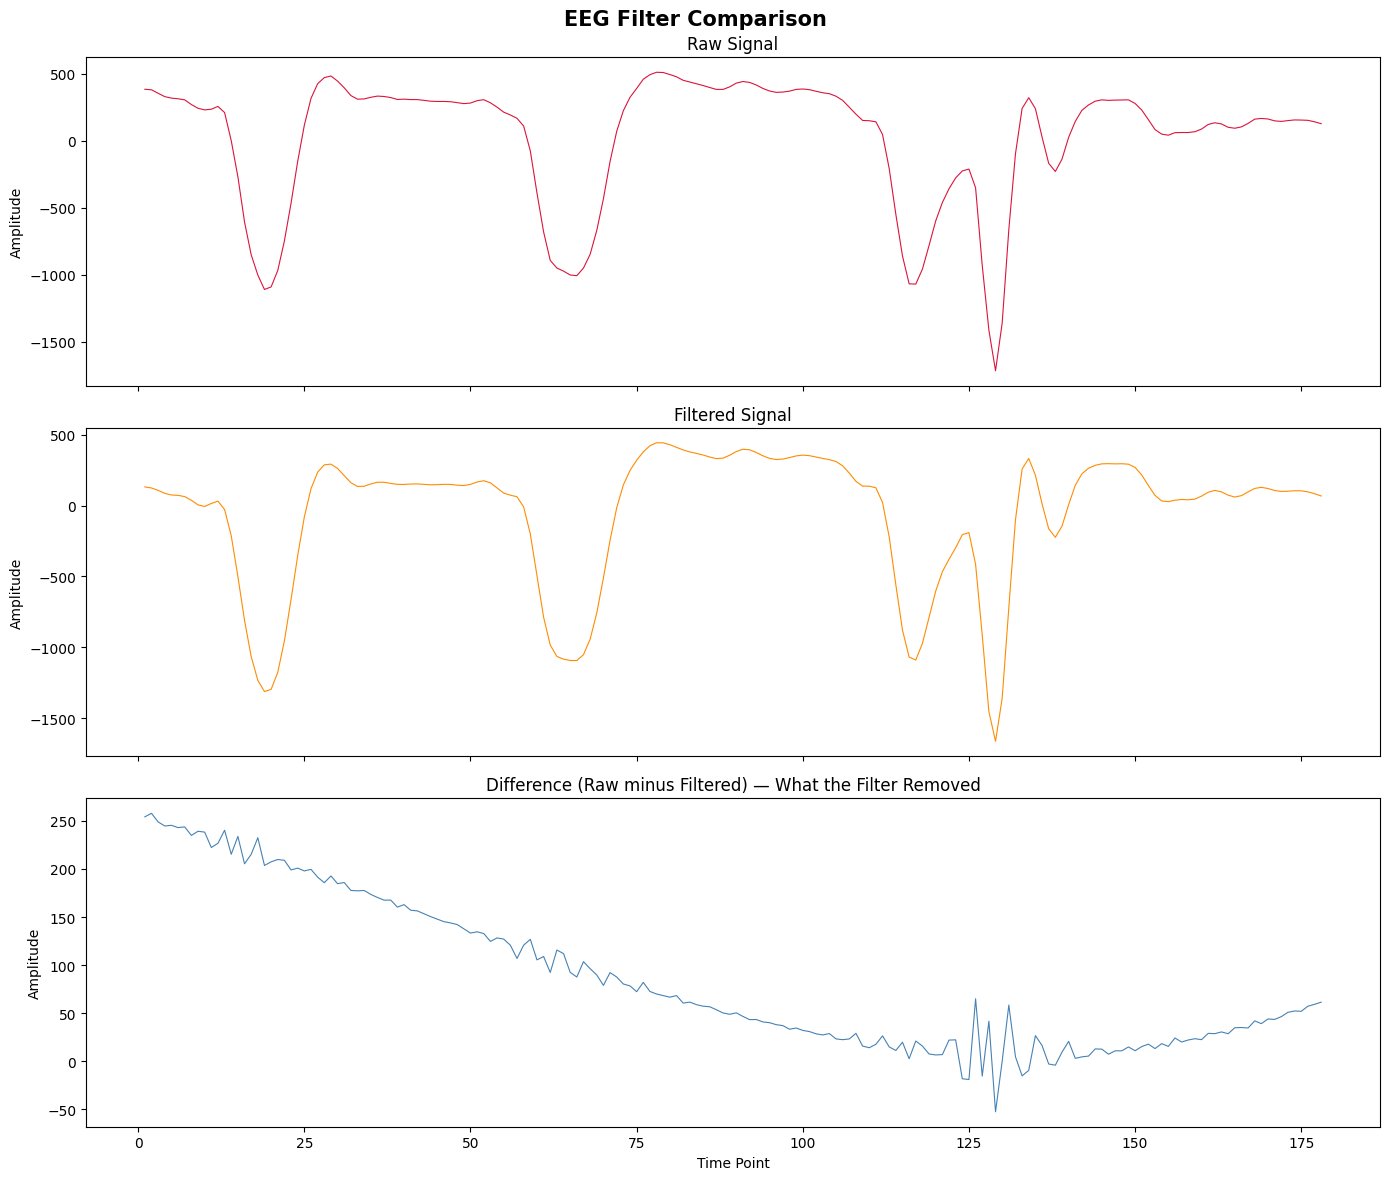

In [ ]:
difference = seizure_sample.values - seizure_filtered

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

ax1.plot(time_points, seizure_sample.values, color='crimson', linewidth=0.8)
ax1.set_title("Raw Signal")
ax1.set_ylabel("Amplitude")

ax2.plot(time_points, seizure_filtered, color='darkorange', linewidth=0.8)
ax2.set_title("Filtered Signal")
ax2.set_ylabel("Amplitude")

ax3.plot(time_points, difference, color='steelblue', linewidth=0.8)
ax3.set_title("Difference (Raw minus Filtered) — What the Filter Removed")
ax3.set_ylabel("Amplitude")
ax3.set_xlabel("Time Point")

plt.suptitle("EEG Filter Comparison", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Extraction
##### Avg. Amplitude | Variance | RMS Amplitude | Dominant Frequency

In [ ]:
from scipy.signal import welch
import numpy as np
import pandas as pd

cols_to_drop = ['avg_amplitude', 'variance', 'rms_amplitude', 'dominant_freq']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

feature_cols = [col for col in df.columns if col.startswith('X')]

avg_amplitudes = []
variances      = []
rms_amplitudes = []
dominant_freqs = []

for _, row in df[feature_cols].iterrows():
    signal = row.values.astype(float)

    avg_amplitudes.append(np.mean(np.abs(signal)))
    variances.append(np.var(signal))
    rms_amplitudes.append(np.sqrt(np.mean(signal**2)))

    freqs, power = welch(signal, fs=178.0, nperseg=64)
    dominant_freqs.append(freqs[np.argmax(power)])

new_features = pd.DataFrame({
    'avg_amplitude' : avg_amplitudes,
    'variance'      : variances,
    'rms_amplitude' : rms_amplitudes,
    'dominant_freq' : dominant_freqs
}, index=df.index)

df = pd.concat([df, new_features], axis=1)

# Confirm it worked
print("New columns added:", ['avg_amplitude', 'variance', 'rms_amplitude', 'dominant_freq'])
print(df[['avg_amplitude', 'variance', 'rms_amplitude', 'dominant_freq', 'y']].head())

New columns added: ['avg_amplitude', 'variance', 'rms_amplitude', 'dominant_freq']
   avg_amplitude       variance  rms_amplitude  dominant_freq  y
0      77.382022    9160.587426      97.193309       13.90625  4
1     375.629213  222629.043555     472.672559        2.78125  1
2      53.921348    1952.436182      62.389048       11.12500  5
3      68.910112     253.564954      70.726010        2.78125  5
4      30.921348    1497.148340      39.260581       11.12500  5


# Mean Power Spectral Density Plot

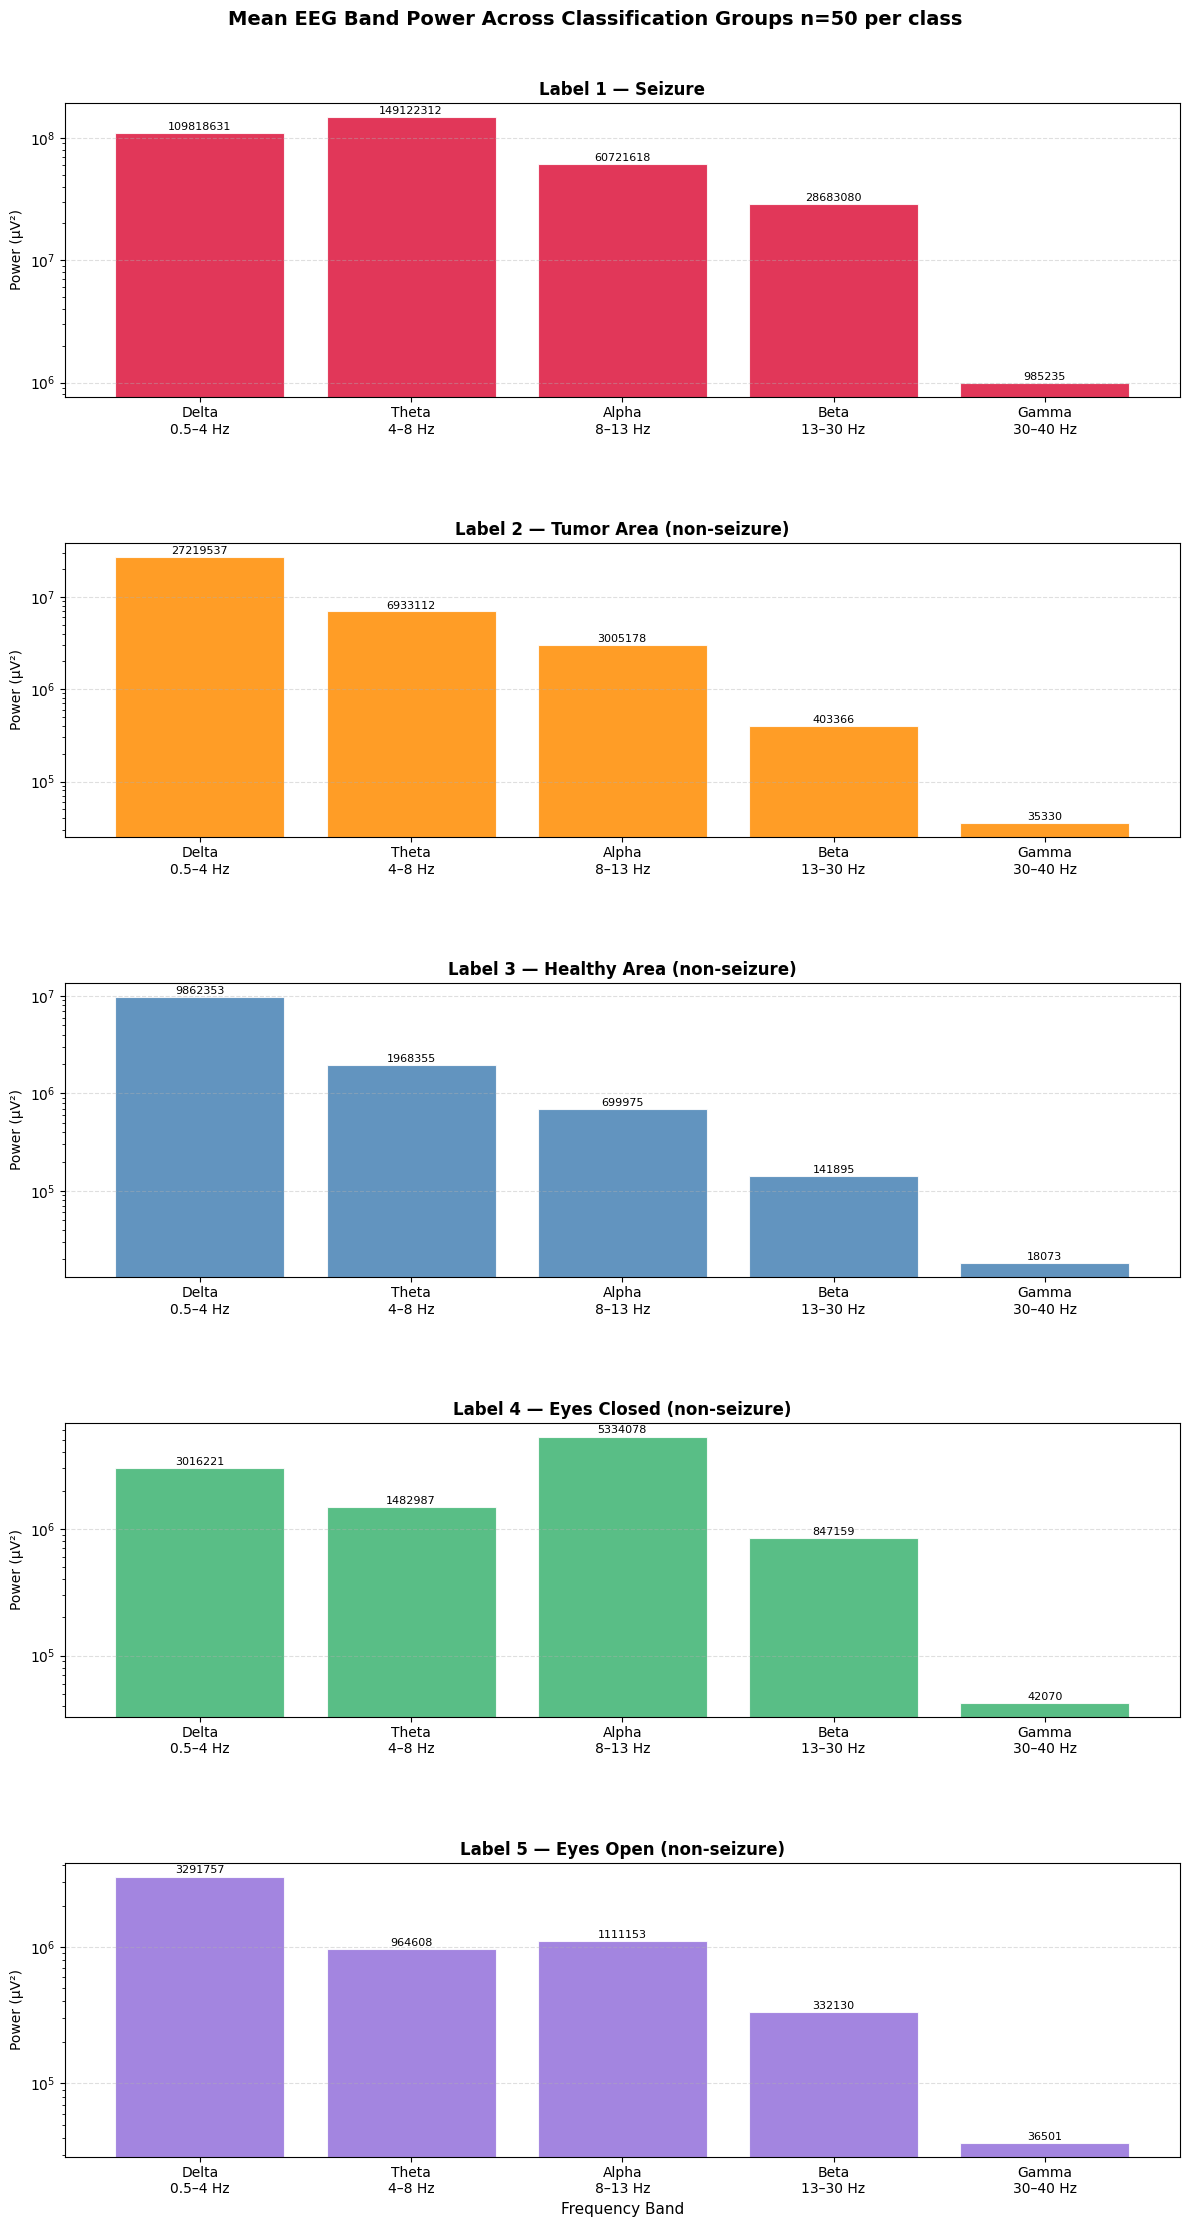

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

label_map = {
    1: "Seizure",
    2: "Tumor Area (non-seizure)",
    3: "Healthy Area (non-seizure)",
    4: "Eyes Closed (non-seizure)",
    5: "Eyes Open (non-seizure)"
}

color_map = {
    1: "crimson",
    2: "darkorange",
    3: "steelblue",
    4: "mediumseagreen",
    5: "mediumpurple"
}

bands = {
    'Delta\n0.5–4 Hz':  (0.5, 4),
    'Theta\n4–8 Hz':    (4, 8),
    'Alpha\n8–13 Hz':   (8, 13),
    'Beta\n13–30 Hz':   (13, 30),
    'Gamma\n30–40 Hz':  (30, 40)
}

feature_cols = [col for col in df.columns if col.startswith('X')]

def compute_band_powers(signal, fs=178.0):
    n = len(signal)
    fft_vals  = np.abs(np.fft.rfft(signal)) ** 2
    fft_freqs = np.fft.rfftfreq(n, d=1/fs)

    powers = {}
    for band_name, (low, high) in bands.items():
        idx = np.where((fft_freqs >= low) & (fft_freqs < high))
        powers[band_name] = np.mean(fft_vals[idx])

    return powers

# Average band power across 50 samples per class for stability
fig, axes = plt.subplots(5, 1, figsize=(12, 22))

for ax, (class_id, label_name) in zip(axes, label_map.items()):

    samples   = df[df['y'] == class_id].head(50)
    all_power = {band: [] for band in bands}

    for _, row in samples.iterrows():
        signal = row[feature_cols].values.astype(float)
        bp     = compute_band_powers(signal)
        for band in bands:
            all_power[band].append(bp[band])

    # Average across 50 samples
    avg_powers  = [np.mean(all_power[band]) for band in bands]
    band_names  = list(bands.keys())

    bars = ax.bar(band_names, avg_powers,
                  color=color_map[class_id],
                  alpha=0.85,
                  edgecolor='white',
                  linewidth=0.8)

    # Add power value labels on top of each bar
    for bar, val in zip(bars, avg_powers):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{val:.0f}',
                ha='center', va='bottom', fontsize=8)

    ax.set_title(f"Label {class_id} — {label_name}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Power (μV²)", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_yscale('log')  # Log scale = power values span orders of magnitude

axes[-1].set_xlabel("Frequency Band", fontsize=11)

plt.suptitle("Mean EEG Band Power Across Classification Groups n=50 per class",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()

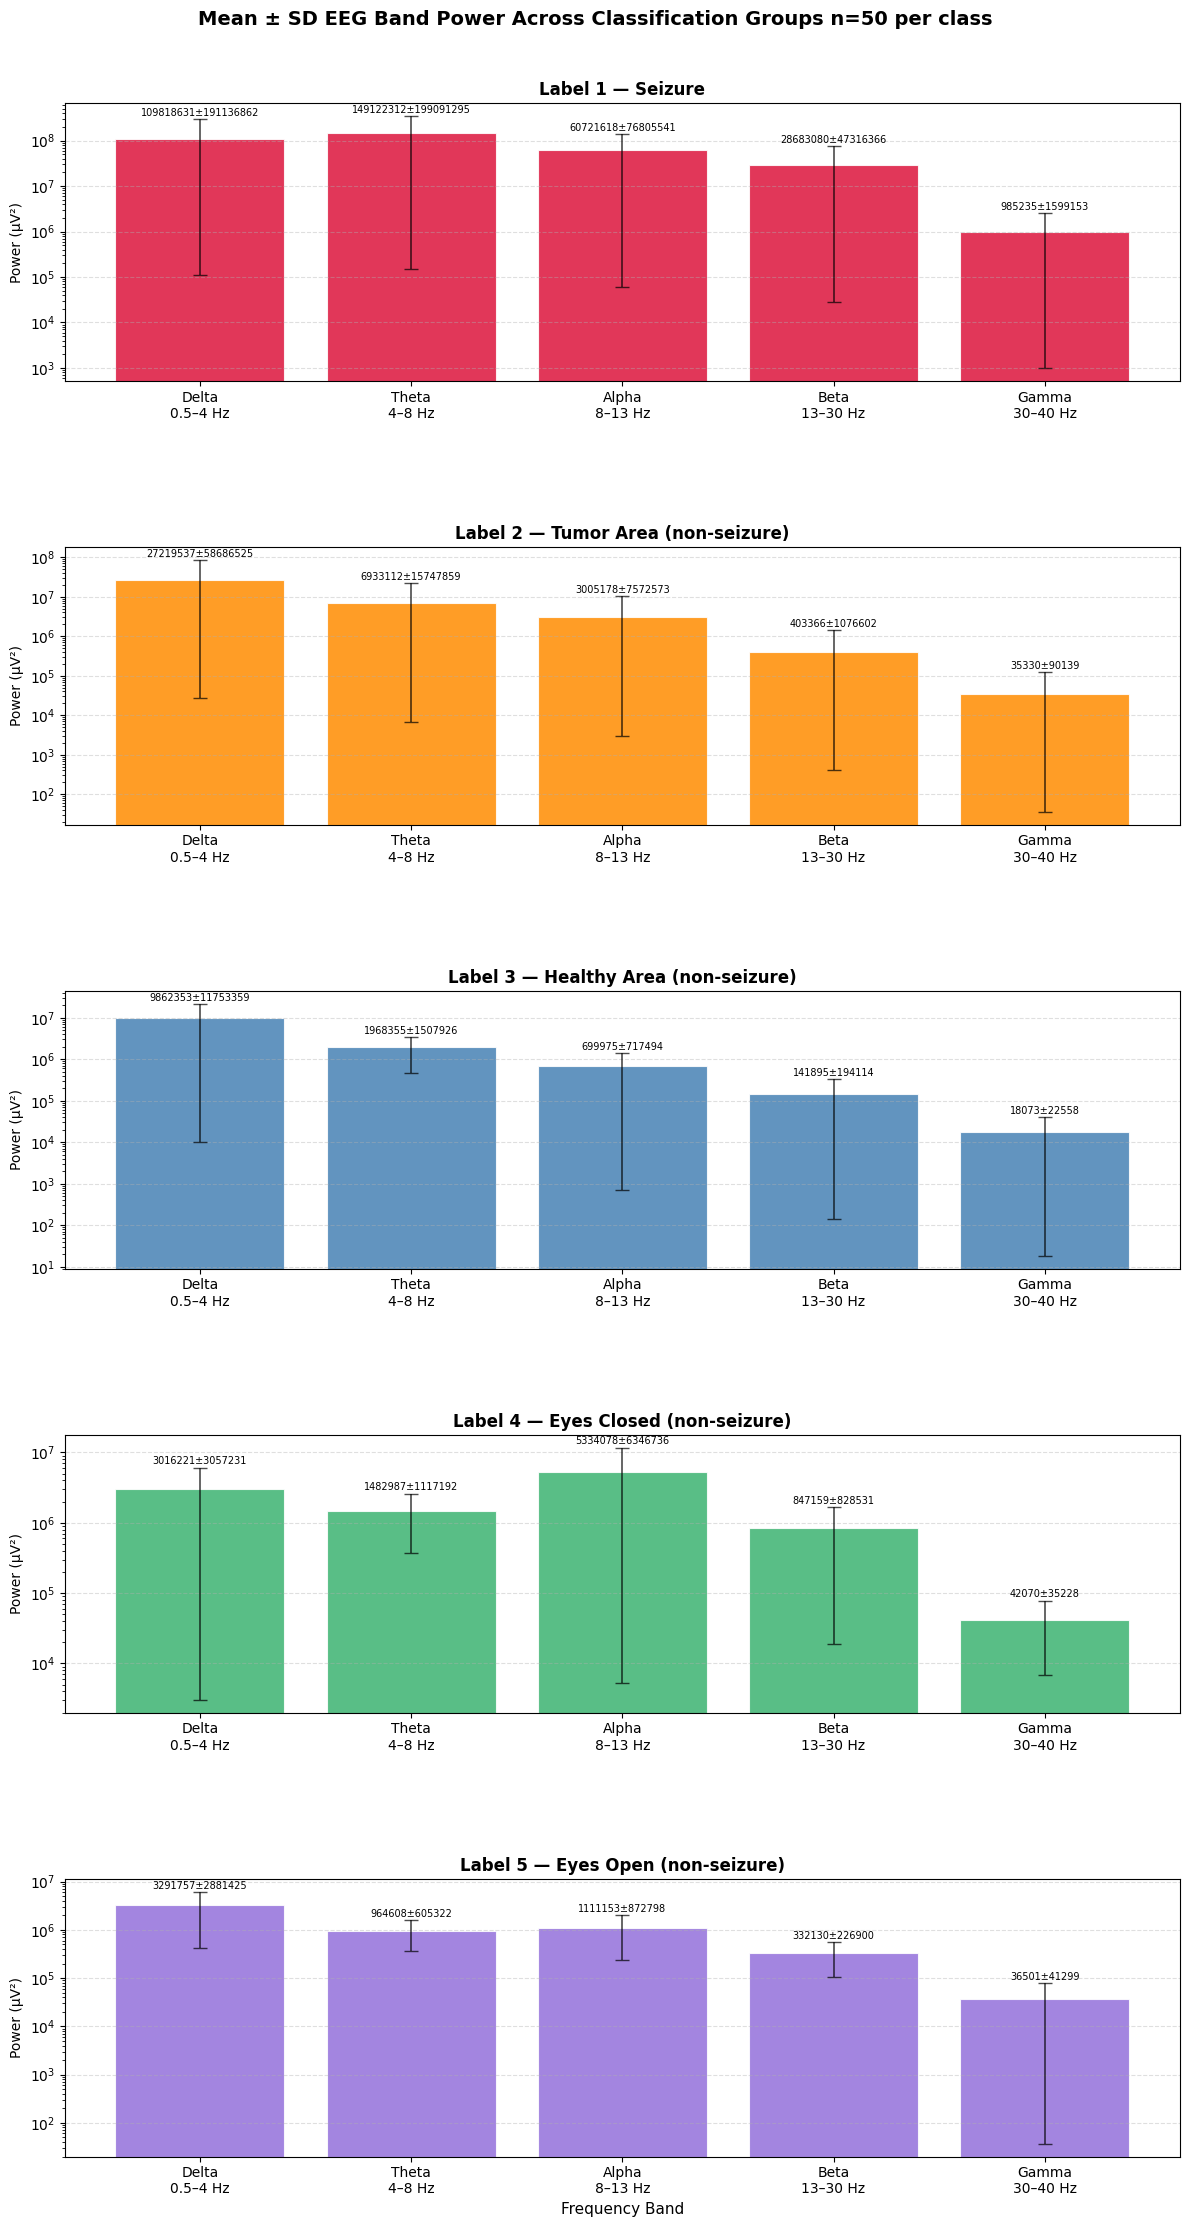

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

label_map = {
    1: "Seizure",
    2: "Tumor Area (non-seizure)",
    3: "Healthy Area (non-seizure)",
    4: "Eyes Closed (non-seizure)",
    5: "Eyes Open (non-seizure)"
}

color_map = {
    1: "crimson",
    2: "darkorange",
    3: "steelblue",
    4: "mediumseagreen",
    5: "mediumpurple"
}

bands = {
    'Delta\n0.5–4 Hz':  (0.5, 4),
    'Theta\n4–8 Hz':    (4, 8),
    'Alpha\n8–13 Hz':   (8, 13),
    'Beta\n13–30 Hz':   (13, 30),
    'Gamma\n30–40 Hz':  (30, 40)
}

feature_cols = [col for col in df.columns if col.startswith('X')]

def compute_band_powers(signal, fs=178.0):
    n = len(signal)
    fft_vals  = np.abs(np.fft.rfft(signal)) ** 2
    fft_freqs = np.fft.rfftfreq(n, d=1/fs)

    powers = {}
    for band_name, (low, high) in bands.items():
        idx = np.where((fft_freqs >= low) & (fft_freqs < high))
        powers[band_name] = np.mean(fft_vals[idx])

    return powers

fig, axes = plt.subplots(5, 1, figsize=(12, 22))

for ax, (class_id, label_name) in zip(axes, label_map.items()):

    samples   = df[df['y'] == class_id].head(50)
    all_power = {band: [] for band in bands}

    for _, row in samples.iterrows():
        signal = row[feature_cols].values.astype(float)
        bp     = compute_band_powers(signal)
        for band in bands:
            all_power[band].append(bp[band])

    # Mean and Standard Deviation across 50 samples
    avg_powers = np.array([np.mean(all_power[band]) for band in bands])
    std_powers = np.array([np.std(all_power[band])  for band in bands])
    band_names = list(bands.keys())

    # Clip lower error bar so mean std never goes <= 0 (required for log scale)
    lower_err = np.minimum(std_powers, avg_powers * 0.999)
    upper_err = std_powers
    error_bars = [lower_err, upper_err]

    bars = ax.bar(band_names, avg_powers,
                  color=color_map[class_id],
                  alpha=0.85,
                  edgecolor='white',
                  linewidth=0.8,
                  yerr=error_bars,
                  capsize=5,
                  error_kw={'elinewidth': 1.2, 'ecolor': 'black', 'alpha': 0.7})

    # Add mean ± SD value labels above each bar's error bar
    for bar, val, sd in zip(bars, avg_powers, std_powers):
        ax.text(bar.get_x() + bar.get_width() / 2,
                (val + sd) * 1.05,
                f'{val:.0f}±{sd:.0f}',
                ha='center', va='bottom', fontsize=7)

    ax.set_title(f"Label {class_id} — {label_name}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Power (μV²)", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_yscale('log')

axes[-1].set_xlabel("Frequency Band", fontsize=11)

plt.suptitle("Mean ± SD EEG Band Power Across Classification Groups n=50 per class",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.show()

In [ ]:
band_cols = ['delta_power', 'theta_power', 'alpha_power',
             'beta_power', 'gamma_power']

summary = df.groupby('y')[band_cols].mean()
summary.index = summary.index.map({
    1: "Seizure", 2: "Tumor Area", 3: "Healthy Area",
    4: "Eyes Closed", 5: "Eyes Open"
})

# Normalize each row so bands are comparable
summary_norm = summary.div(summary.sum(axis=1), axis=0)
print(summary_norm.round(3))

              delta_power  theta_power  alpha_power  beta_power  gamma_power
y                                                                           
Seizure             0.270        0.473        0.180       0.074        0.003
Tumor Area          0.729        0.191        0.069       0.010        0.001
Healthy Area        0.713        0.201        0.071       0.013        0.002
Eyes Closed         0.267        0.141        0.516       0.071        0.004
Eyes Open           0.544        0.197        0.193       0.060        0.007


# FFT Band Power Feature Extraction

In [ ]:
import numpy as np
import pandas as pd

def extract_band_powers(signal, fs=178.0):
    n = len(signal)
    fft_vals = np.abs(np.fft.rfft(signal)) ** 2
    fft_freqs = np.fft.rfftfreq(n, d=1/fs)

    bands = {
        'delta_power': (0.5, 4),
        'theta_power': (4, 8),
        'alpha_power': (8, 13),
        'beta_power':  (13, 30),
        'gamma_power': (30, 40)
    }

    powers = {}
    for band_name, (low, high) in bands.items():
        idx = np.where((fft_freqs >= low) & (fft_freqs < high))
        powers[band_name] = np.mean(fft_vals[idx])

    return powers

# Drop if already exist
band_cols = ['delta_power', 'theta_power', 'alpha_power', 'beta_power', 'gamma_power']
df = df.drop(columns=[c for c in band_cols if c in df.columns])

feature_cols = [col for col in df.columns if col.startswith('X')]

# Extract for every recording
band_records = []
for _, row in df[feature_cols].iterrows():
    signal = row.values.astype(float)
    band_records.append(extract_band_powers(signal))

band_df = pd.DataFrame(band_records, index=df.index)
df = pd.concat([df, band_df], axis=1)

print("Band powers added. Shape:", df.shape)
print(df[band_cols + ['y']].head())

Band powers added. Shape: (11500, 191)
    delta_power   theta_power   alpha_power    beta_power    gamma_power  y
0  1.212764e+07  2.690211e+06  3.642091e+06  4.581871e+06   90571.245156  4
1  4.356543e+08  2.791121e+08  1.070231e+08  3.265816e+07  991340.526025  1
2  2.957464e+06  1.485472e+06  1.858969e+06  3.772791e+05   31610.986634  5
3  3.627915e+05  1.703431e+05  1.560892e+05  7.493452e+04    9623.056721  5
4  2.855970e+06  5.153526e+05  7.299272e+05  5.114793e+05   48436.300397  5


# Saving Data Features Dataframe

In [ ]:
import pandas as pd
import numpy as np

# Save all extracted features including the new ones
features_df = df[['avg_amplitude', 'variance', 'rms_amplitude',
                   'dominant_freq', 'delta_power', 'theta_power',
                   'alpha_power', 'beta_power', 'gamma_power', 'y']].copy()

print(features_df.head())
print("Shape:", features_df.shape)

features_df.to_csv("processed_features.csv", index=False)
print("Saved to processed_features.csv")

   avg_amplitude       variance  rms_amplitude  dominant_freq   delta_power  \
0      77.382022    9160.587426      97.193309       13.90625  1.212764e+07   
1     375.629213  222629.043555     472.672559        2.78125  4.356543e+08   
2      53.921348    1952.436182      62.389048       11.12500  2.957464e+06   
3      68.910112     253.564954      70.726010        2.78125  3.627915e+05   
4      30.921348    1497.148340      39.260581       11.12500  2.855970e+06   

    theta_power   alpha_power    beta_power    gamma_power  y  
0  2.690211e+06  3.642091e+06  4.581871e+06   90571.245156  4  
1  2.791121e+08  1.070231e+08  3.265816e+07  991340.526025  1  
2  1.485472e+06  1.858969e+06  3.772791e+05   31610.986634  5  
3  1.703431e+05  1.560892e+05  7.493452e+04    9623.056721  5  
4  5.153526e+05  7.299272e+05  5.114793e+05   48436.300397  5  
Shape: (11500, 10)
Saved to processed_features.csv


# Total Accuracy Comparison Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

feature_cols = [col for col in df.columns if col.startswith('X')]
y = df['y']

# Shared constraints for fair comparison
params = dict(
    n_estimators=200, max_depth=12, min_samples_split=20,
    min_samples_leaf=8, max_features='sqrt', random_state=42
)

# Model 1: Raw 178 Time Points
X_raw = df[feature_cols]
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)
model_r = RandomForestClassifier(**params)
model_r.fit(X_train_r, y_train_r)
train_acc_r = accuracy_score(y_train_r, model_r.predict(X_train_r))
test_acc_r  = accuracy_score(y_test_r,  model_r.predict(X_test_r))

# Model 2: 4 Extracted Features Only
four_features = ['avg_amplitude', 'variance', 'rms_amplitude', 'dominant_freq']
X_four = df[four_features]
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(
    X_four, y, test_size=0.2, random_state=42
)
model_4 = RandomForestClassifier(**params)
model_4.fit(X_train_4, y_train_4)
train_acc_4 = accuracy_score(y_train_4, model_4.predict(X_train_4))
test_acc_4  = accuracy_score(y_test_4,  model_4.predict(X_test_4))

# Model 3: 5 FFT Band Power Features Only
band_features = ['delta_power', 'theta_power', 'alpha_power',
                 'beta_power', 'gamma_power']
X_band = df[band_features]
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_band, y, test_size=0.2, random_state=42
)
model_b = RandomForestClassifier(**params)
model_b.fit(X_train_b, y_train_b)
train_acc_b = accuracy_score(y_train_b, model_b.predict(X_train_b))
test_acc_b  = accuracy_score(y_test_b,  model_b.predict(X_test_b))

# Model 4: FFT Band Power + Raw EEG
combined_raw = feature_cols + band_features
X_raw_band = df[combined_raw]
X_train_rb, X_test_rb, y_train_rb, y_test_rb = train_test_split(
    X_raw_band, y, test_size=0.2, random_state=42
)
model_rb = RandomForestClassifier(**params)
model_rb.fit(X_train_rb, y_train_rb)
train_acc_rb = accuracy_score(y_train_rb, model_rb.predict(X_train_rb))
test_acc_rb  = accuracy_score(y_test_rb,  model_rb.predict(X_test_rb))

# Model 5: All 9 Features (4 Extracted + 5 FFT Band Powers)
all_features = four_features + band_features
X_all = df[all_features]
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)
model_a = RandomForestClassifier(**params)
model_a.fit(X_train_a, y_train_a)
train_acc_a = accuracy_score(y_train_a, model_a.predict(X_train_a))
test_acc_a  = accuracy_score(y_test_a,  model_a.predict(X_test_a))

# Full Comparison Table
print("=" * 62)
print(f"{'Model':<38} {'Train':>6}  {'Test':>6}  {'Gap':>6}")
print("=" * 62)
print(f"{'Raw 178 Time Points':<38} {train_acc_r:.4f}  {test_acc_r:.4f}  {train_acc_r - test_acc_r:.4f}")
print(f"{'4 Extracted Features':<38} {train_acc_4:.4f}  {test_acc_4:.4f}  {train_acc_4 - test_acc_4:.4f}")
print(f"{'5 FFT Band Powers Only':<38} {train_acc_b:.4f}  {test_acc_b:.4f}  {train_acc_b - test_acc_b:.4f}")
print(f"{'Raw EEG + FFT Band Powers':<38} {train_acc_rb:.4f}  {test_acc_rb:.4f}  {train_acc_rb - test_acc_rb:.4f}")
print(f"{'All 9 Features (4 + FFT)':<38} {train_acc_a:.4f}  {test_acc_a:.4f}  {train_acc_a - test_acc_a:.4f}")
print("=" * 62)

Model                                   Train    Test     Gap
Raw 178 Time Points                    0.6458  0.5783  0.0675
4 Extracted Features                   0.7123  0.6087  0.1036
5 FFT Band Powers Only                 0.8305  0.7396  0.0910
Raw EEG + FFT Band Powers              0.8529  0.7352  0.1177
All 9 Features (4 + FFT)               0.8426  0.7630  0.0796


# Accuracy Comparison


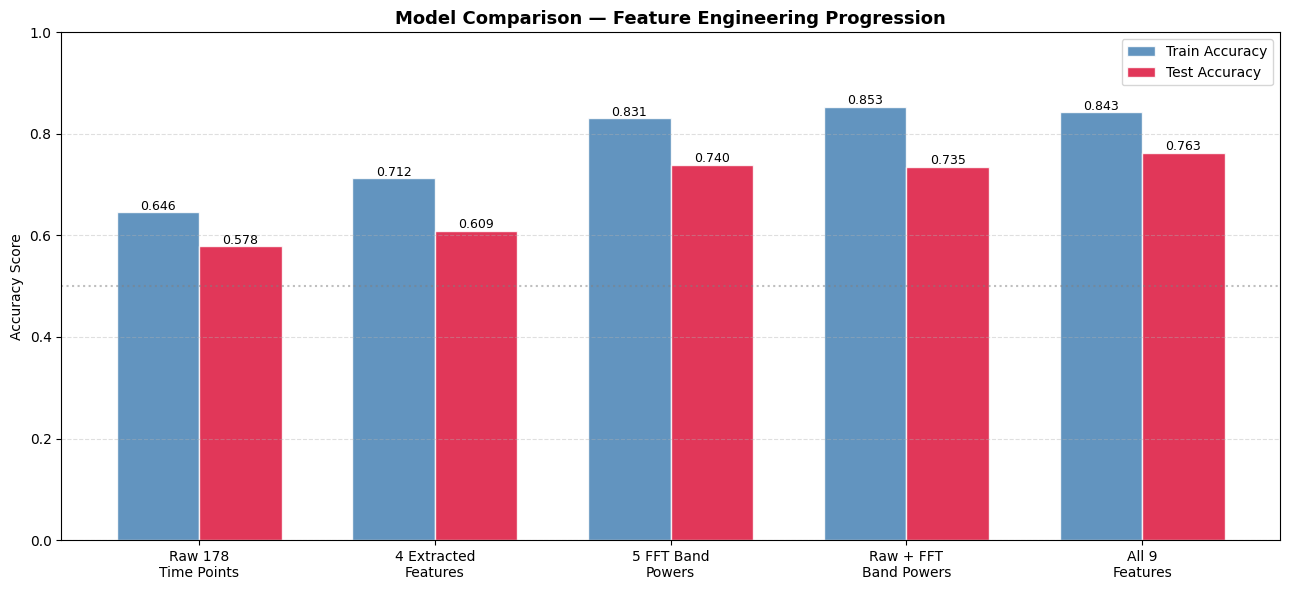

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models     = ['Raw 178\nTime Points', '4 Extracted\nFeatures',
              '5 FFT Band\nPowers', 'Raw + FFT\nBand Powers',
              'All 9\nFeatures']
train_accs = [0.6458, 0.7123, 0.8305, 0.8529, 0.8426]
test_accs  = [0.5783, 0.6087, 0.7396, 0.7352, 0.7630]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy',
               color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test Accuracy',
               color='crimson',   alpha=0.85, edgecolor='white')

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_title('Model Comparison — Feature Engineering Progression',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy Score')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Chance level')

plt.tight_layout()
plt.show()

# Confusion Matrix

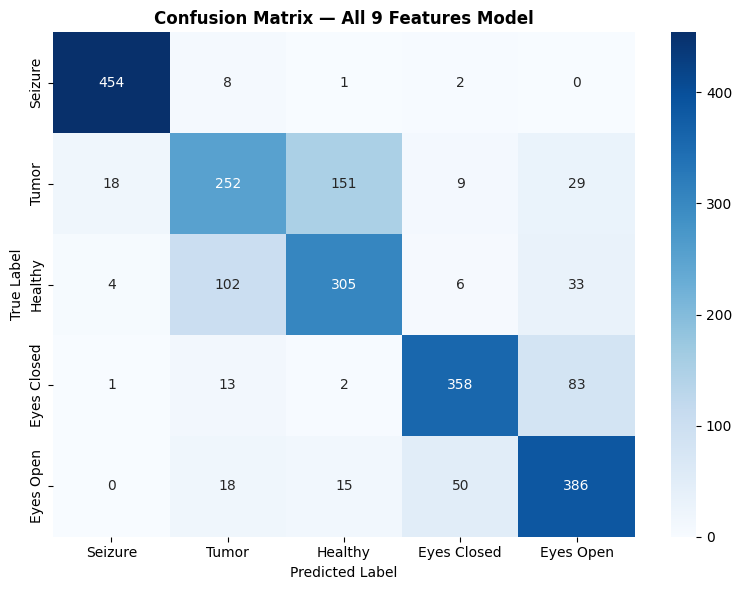

              precision    recall  f1-score   support

     Seizure       0.95      0.98      0.96       465
       Tumor       0.64      0.55      0.59       459
     Healthy       0.64      0.68      0.66       450
 Eyes Closed       0.84      0.78      0.81       457
   Eyes Open       0.73      0.82      0.77       469

    accuracy                           0.76      2300
   macro avg       0.76      0.76      0.76      2300
weighted avg       0.76      0.76      0.76      2300



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test_a, model_a.predict(X_test_a))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Seizure', 'Tumor', 'Healthy', 'Eyes Closed', 'Eyes Open'],
            yticklabels=['Seizure', 'Tumor', 'Healthy', 'Eyes Closed', 'Eyes Open'])
ax.set_title('Confusion Matrix — All 9 Features Model', fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(y_test_a, model_a.predict(X_test_a),
      target_names=['Seizure', 'Tumor', 'Healthy', 'Eyes Closed', 'Eyes Open']))

# Feature Importance

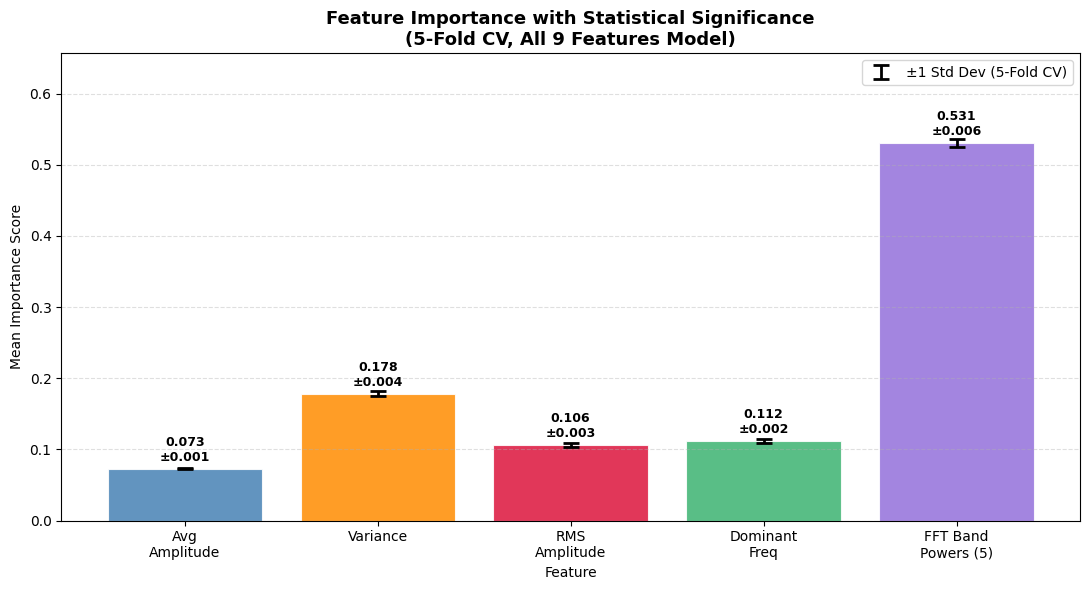

   FEATURE IMPORTANCE REPORT — All 9 Features
  Avg Amplitude          0.0730 ± 0.0008  ███████
  Variance               0.1781 ± 0.0035  █████████████████
  RMS Amplitude          0.1062 ± 0.0032  ██████████
  Dominant Freq          0.1119 ± 0.0023  ███████████
  FFT Band Powers (5)    0.5308 ± 0.0062  █████████████████████████████████████████████████████

  FFT Band Powers share of total importance: 53.1%
  4 Features share of total importance: 46.9%
   FEATURE IMPORTANCE REPORT — All 9 Features
  Avg Amplitude          0.0730 ± 0.0008  ███████
  Variance               0.1781 ± 0.0035  █████████████████
  RMS Amplitude          0.1062 ± 0.0032  ██████████
  Dominant Freq          0.1119 ± 0.0023  ███████████
  FFT Band Powers (5)    0.5308 ± 0.0062  █████████████████████████████████████████████████████

  FFT Band Powers share of total importance: 53.1%
  4 Features share of total importance: 46.9%

   MODEL PERFORMANCE SUMMARY
  Model Trained On : All 9 Features (4 Extracted + 5 FFT

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

four_features = ['avg_amplitude', 'variance', 'rms_amplitude', 'dominant_freq']
band_features = ['delta_power', 'theta_power', 'alpha_power', 'beta_power', 'gamma_power']
all_features  = four_features + band_features
y = df['y']

params = dict(n_estimators=200, max_depth=12, min_samples_split=20,
              min_samples_leaf=8, max_features='sqrt', random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train on All 9 Features
X_all = df[all_features]
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Collect Feature Importances Across CV Folds
fold_importances = []
for train_idx, val_idx in cv.split(X_train, y_train):
    fold_model = RandomForestClassifier(**params)
    fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    fold_importances.append(fold_model.feature_importances_)

fold_importances = np.array(fold_importances)
imp_means = fold_importances.mean(axis=0)
imp_stds  = fold_importances.std(axis=0)

# Group FFT into One Combined Bar
four_means = imp_means[:4]
four_stds  = imp_stds[:4]
fft_mean   = np.sum(imp_means[4:])
fft_std    = np.sqrt(np.sum(imp_stds[4:] ** 2))

plot_names  = ['Avg\nAmplitude', 'Variance', 'RMS\nAmplitude',
               'Dominant\nFreq', 'FFT Band\nPowers (5)']
plot_means  = list(four_means) + [fft_mean]
plot_stds   = list(four_stds)  + [fft_std]
plot_colors = ['steelblue', 'darkorange', 'crimson',
               'mediumseagreen', 'mediumpurple']

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(plot_names, plot_means, color=plot_colors,
              alpha=0.85, edgecolor='white', linewidth=0.8)

ax.errorbar(range(len(plot_names)), plot_means, yerr=plot_stds,
            fmt='none', color='black',
            capsize=6, capthick=2, elinewidth=2,
            label='±1 Std Dev (5-Fold CV)')

for bar, mean, std in zip(bars, plot_means, plot_stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(plot_stds) + 0.005,
            f'{mean:.3f}\n±{std:.3f}',
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Feature Importance with Statistical Significance\n(5-Fold CV, All 9 Features Model)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Importance Score')
ax.set_xlabel('Feature')
ax.set_ylim(0, max(plot_means) + max(plot_stds) + 0.12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
print("=" * 55)

# Train final model for accuracy and per class report
final_model = RandomForestClassifier(**params)
final_model.fit(X_train, y_train)
predictions   = final_model.predict(X_test)
train_acc     = accuracy_score(y_train, final_model.predict(X_train))
test_acc      = accuracy_score(y_test, predictions)

# Full Report
print("=" * 55)
print("   FEATURE IMPORTANCE REPORT — All 9 Features")
print("=" * 55)
for name, mean, std in zip(plot_names, plot_means, plot_stds):
    bar  = '█' * int(mean * 100)
    name = name.replace('\n', ' ')
    print(f"  {name:<22} {mean:.4f} ± {std:.4f}  {bar}")

print(f"\n  FFT Band Powers share of"
      f" total importance: {fft_mean / sum(plot_means) * 100:.1f}%")
print(f"  4 Features share of"
      f" total importance: {sum(four_means) / sum(plot_means) * 100:.1f}%")

print("\n" + "=" * 55)
print("   MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(f"  Model Trained On : All 9 Features (4 Extracted + 5 FFT)")
print(f"  Train Accuracy   : {train_acc:.4f}")
print(f"  Test Accuracy    : {test_acc:.4f}")
print(f"  Generalization   : {train_acc - test_acc:.4f} gap")

print("\n" + "=" * 55)
print("   PER CLASS PERFORMANCE")
print("=" * 55)
print(classification_report(y_test, predictions,
      target_names=['Seizure', 'Tumor Area',
                    'Healthy Area', 'Eyes Closed', 'Eyes Open']))
print("=" * 55)